# 附：Codes

<!-- limit_dep_models_codes.ipynb -->

生成 `limit_dep_models_lec.qmd` 中所需的主要图片，并将模拟数据保存到 `./data/`。

**图片列表**：

- `limit_dep_models_fig01_model_map.png`
- `limit_dep_models_fig02_capex_distribution.png`
- `limit_dep_models_fig03_tobit_latent_observed.png`
- `limit_dep_models_fig04_tobit_effects.png`
- `limit_dep_models_fig05_twopart_flow.png`
- `limit_dep_models_fig06_hurdle_gates.png`
- `limit_dep_models_fig07_heckman_selection.png`
- `limit_dep_models_fig08_treatment_selection.png`
- `limit_dep_models_fig09_flow_distribution.png`
- `limit_dep_models_fig10_ppml_vs_logols.png`

In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy.stats import norm

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.20,
    'figure.dpi': 150,
})

BLUE = '#3B82C4'
ORANGE = '#D96B3B'
GREEN = '#4D8B31'
RED = '#B94A48'
GRAY = '#7A7A7A'
LIGHT = '#E8EEF5'

BASE_DIR = '.'
FIG_DIR = os.path.join(BASE_DIR, 'figs')
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

def save_fig(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved: {path}')

def panel_title(ax, text):
    ax.text(0.02, 0.98, text, transform=ax.transAxes, ha='left', va='top',
            fontsize=11, fontweight='bold')

np.random.seed(42)

## 1. 模拟数据：主案例与扩展案例

In [17]:
N = 1500
size = np.clip(np.random.normal(8.2, 1.1, N), 5.5, 11.5)
cashflow = np.random.normal(0.08, 0.06, N)
leverage = np.clip(np.random.normal(0.45, 0.16, N), 0.05, 0.95)
growth = np.random.normal(0.10, 0.18, N)
digital_policy = np.random.binomial(1, 0.35, N)
disclosure = np.random.binomial(1, 0.55, N)
region_open = np.random.binomial(1, 0.40, N)

eps = np.random.normal(0, 28, N)
capex_star = 35 + 120 * cashflow - 42 * leverage + 18 * growth + 7 * (size - 8) + eps
capex = np.maximum(0, capex_star)

part_index = -0.4 + 1.0 * digital_policy + 0.9 * cashflow - 1.2 * leverage + 0.3 * growth + np.random.normal(0, 0.9, N)
participate = (part_index > 0).astype(int)
intensity_star = 20 + 90 * cashflow - 30 * leverage + 10 * growth + 5 * (size - 8) + np.random.normal(0, 18, N)
twopart_y = participate * np.maximum(0, intensity_star)

hurdle_index = -0.8 + 1.1 * digital_policy + 0.5 * region_open + 0.7 * cashflow + np.random.normal(0, 0.8, N)
gate = (hurdle_index > 0).astype(int)
hurdle_star = 12 + 60 * cashflow - 18 * leverage + 12 * growth + np.random.normal(0, 16, N)
hurdle_y = gate * np.maximum(0, hurdle_star)

select_star = -0.3 + 0.9 * disclosure + 0.6 * region_open + 0.4 * (size - 8) + np.random.normal(0, 0.8, N)
selected = (select_star > 0).astype(int)
donation_star = 6 + 25 * cashflow - 12 * leverage + 5 * growth + np.random.normal(0, 7, N)
donation_obs = np.where(selected == 1, np.maximum(0, donation_star), np.nan)

treat_star = -0.6 + 1.2 * digital_policy + 0.8 * region_open + 0.4 * growth + np.random.normal(0, 0.9, N)
treated = (treat_star > 0).astype(int)
invest_after = 20 + 15 * treated + 55 * cashflow - 18 * leverage + 8 * growth + np.random.normal(0, 15, N)

pairs = 2400
distance = np.random.gamma(2.0, 2.0, pairs)
market_size = np.random.normal(8.5, 1.0, pairs)
policy = np.random.binomial(1, 0.3, pairs)
mu = np.exp(-1.2 - 0.22 * distance + 0.18 * market_size + 0.20 * policy)
trade_flow = np.random.poisson(mu)

capex_df = pd.DataFrame({
    'size': size,
    'cashflow': cashflow,
    'leverage': leverage,
    'growth': growth,
    'digital_policy': digital_policy,
    'disclosure': disclosure,
    'region_open': region_open,
    'capex_star': capex_star,
    'capex': capex,
    'participate': participate,
    'twopart_y': twopart_y,
    'gate': gate,
    'hurdle_y': hurdle_y,
    'selected': selected,
    'donation_obs': donation_obs,
    'treated': treated,
    'invest_after': invest_after
})
flow_df = pd.DataFrame({
    'distance': distance,
    'market_size': market_size,
    'policy': policy,
    'trade_flow': trade_flow
})

capex_df.to_csv(os.path.join(DATA_DIR, 'limit_dep_models_data01_capex_sim.csv'), index=False)
flow_df.to_csv(os.path.join(DATA_DIR, 'limit_dep_models_data02_flow_sim.csv'), index=False)
print('Saved simulated datasets to ./data/')
print(capex_df[['capex', 'twopart_y', 'hurdle_y', 'donation_obs', 'invest_after']].describe().round(2))

Saved simulated datasets to ./data/
         capex  twopart_y  hurdle_y  donation_obs  invest_after
count  1500.00    1500.00   1500.00       1054.00       1500.00
mean     31.57       6.52      5.81          4.80         24.95
std      25.95      13.41     11.02          5.54         17.52
min       0.00       0.00      0.00          0.00        -40.28
25%       8.53       0.00      0.00          0.00         13.12
50%      28.29       0.00      0.00          3.09         25.09
75%      49.44       3.00      7.52          7.87         36.29
max     117.27      74.35     61.25         33.27         76.25


## 2. fig01：模型选择路线图

Saved: .\figs\limit_dep_models_fig01_model_map.png


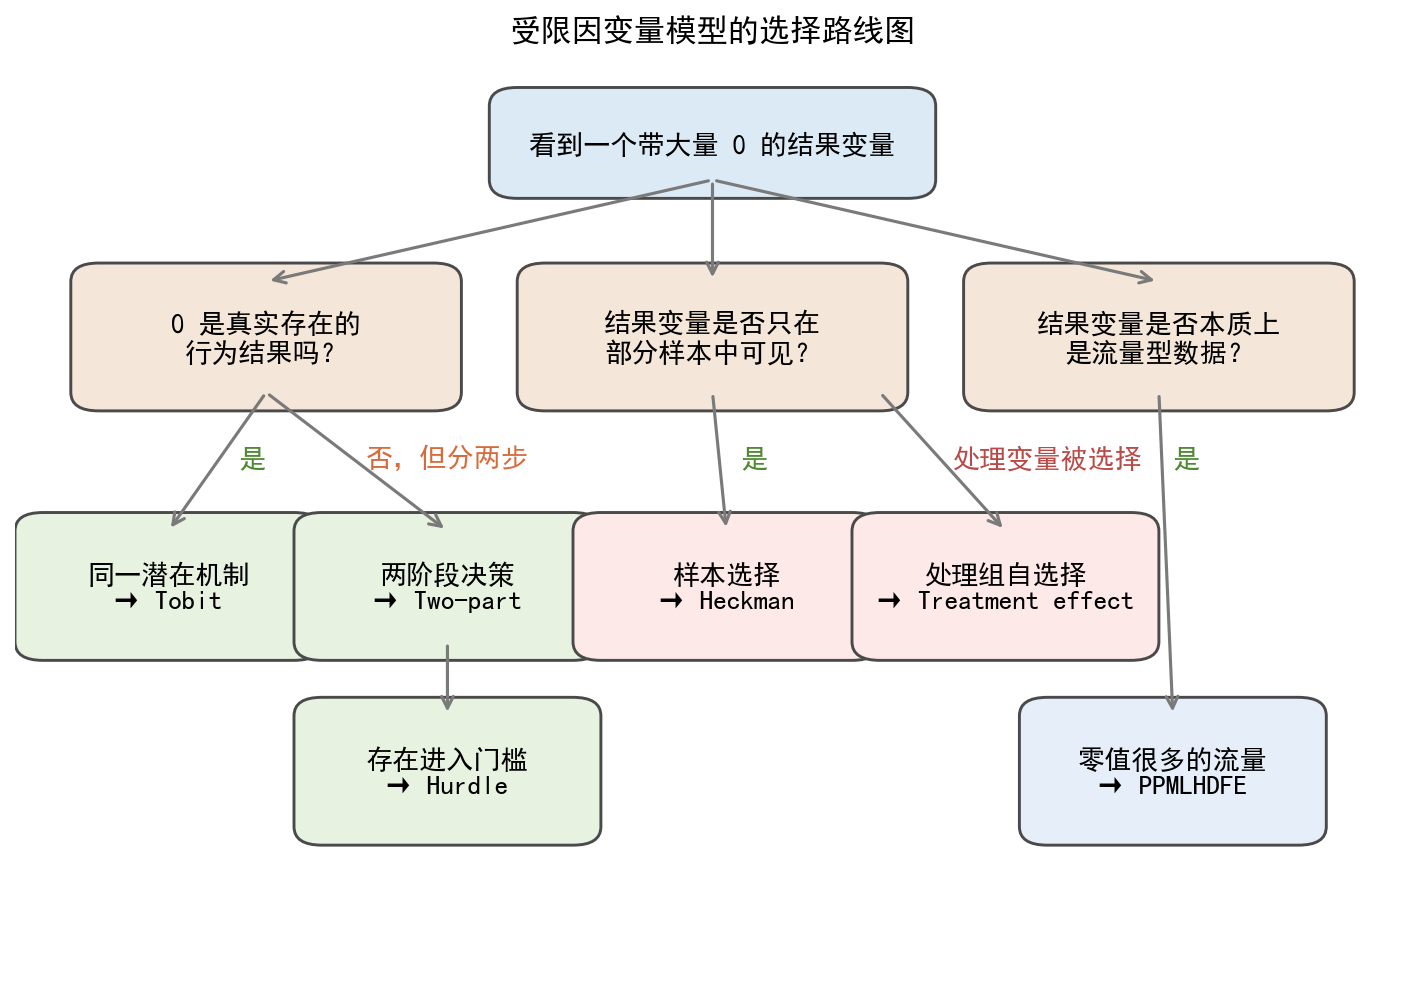

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_axis_off()

def box(x, y, w, h, text, fc=LIGHT, ec='#4A4A4A', fs=13):
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.02',
                           linewidth=1.4, edgecolor=ec, facecolor=fc)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=fs)

def arrow(x1, y1, x2, y2):
    arr = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=14,
                         linewidth=1.5, color=GRAY)
    ax.add_patch(arr)

box(0.36, 0.88, 0.28, 0.08, '看到一个带大量 0 的结果变量', fc='#DCEAF6', fs=13)
box(0.06, 0.65, 0.24, 0.12, '0 是真实存在的\n行为结果吗？', fc='#F4E6D8')
box(0.38, 0.65, 0.24, 0.12, '结果变量是否只在\n部分样本中可见？', fc='#F4E6D8')
box(0.70, 0.65, 0.24, 0.12, '结果变量是否本质上\n是流量型数据？', fc='#F4E6D8')

box(0.02, 0.38, 0.18, 0.12, '同一潜在机制\n→ Tobit', fc='#E7F2E1')
box(0.22, 0.38, 0.18, 0.12, '两阶段决策\n→ Two-part', fc='#E7F2E1')
box(0.22, 0.18, 0.18, 0.12, '存在进入门槛\n→ Hurdle', fc='#E7F2E1')
box(0.42, 0.38, 0.18, 0.12, '样本选择\n→ Heckman', fc='#FDE9E7')
box(0.62, 0.38, 0.18, 0.12, '处理组自选择\n→ Treatment effect', fc='#FDE9E7')
box(0.74, 0.18, 0.18, 0.12, '零值很多的流量\n→ PPMLHDFE', fc='#E6EEF9')

arrow(0.50, 0.88, 0.18, 0.77)
arrow(0.50, 0.88, 0.50, 0.77)
arrow(0.50, 0.88, 0.82, 0.77)
arrow(0.18, 0.65, 0.11, 0.50)
arrow(0.18, 0.65, 0.31, 0.50)
arrow(0.31, 0.38, 0.31, 0.30)
arrow(0.50, 0.65, 0.51, 0.50)
arrow(0.62, 0.65, 0.71, 0.50)
arrow(0.82, 0.65, 0.83, 0.30)

ax.text(0.16, 0.57, '是', color=GREEN, fontsize=13, fontweight='bold')
ax.text(0.31, 0.57, '否，但分两步', color=ORANGE, fontsize=13, fontweight='bold', ha='center')
ax.text(0.52, 0.57, '是', color=GREEN, fontsize=13, fontweight='bold')
ax.text(0.74, 0.57, '处理变量被选择', color=RED, fontsize=13, fontweight='bold', ha='center')
ax.text(0.83, 0.57, '是', color=GREEN, fontsize=13, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('受限因变量模型的选择路线图', fontsize=15, pad=14)
save_fig(fig, 'limit_dep_models_fig01_model_map.png')
plt.show()

## 3. fig02：企业资本开支的典型分布

Saved: .\figs\limit_dep_models_fig02_capex_distribution.png


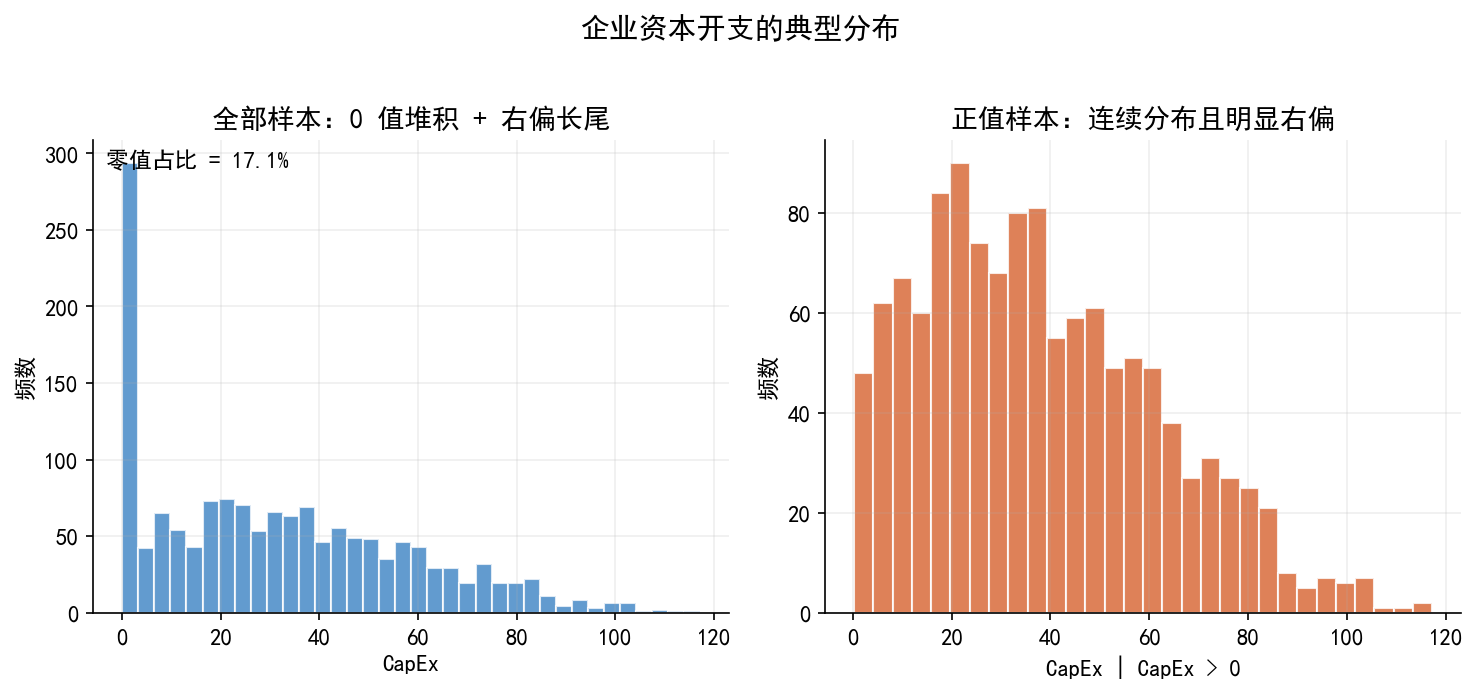

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].hist(capex_df['capex'], bins=36, color=BLUE, alpha=0.80, edgecolor='white')
axes[0].set_xlabel('CapEx')
axes[0].set_ylabel('频数')
axes[0].set_title('全部样本：0 值堆积 + 右偏长尾')
panel_title(axes[0], f"零值占比 = {(capex_df['capex'] == 0).mean():.1%}")

positive_capex = capex_df.loc[capex_df['capex'] > 0, 'capex']
axes[1].hist(positive_capex, bins=30, color=ORANGE, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('CapEx | CapEx > 0')
axes[1].set_ylabel('频数')
axes[1].set_title('正值样本：连续分布且明显右偏')

fig.suptitle('企业资本开支的典型分布', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'limit_dep_models_fig02_capex_distribution.png')
plt.show()

## 4. fig03：Tobit 的潜变量与观测变量

Saved: .\figs\limit_dep_models_fig03_tobit_latent_observed.png


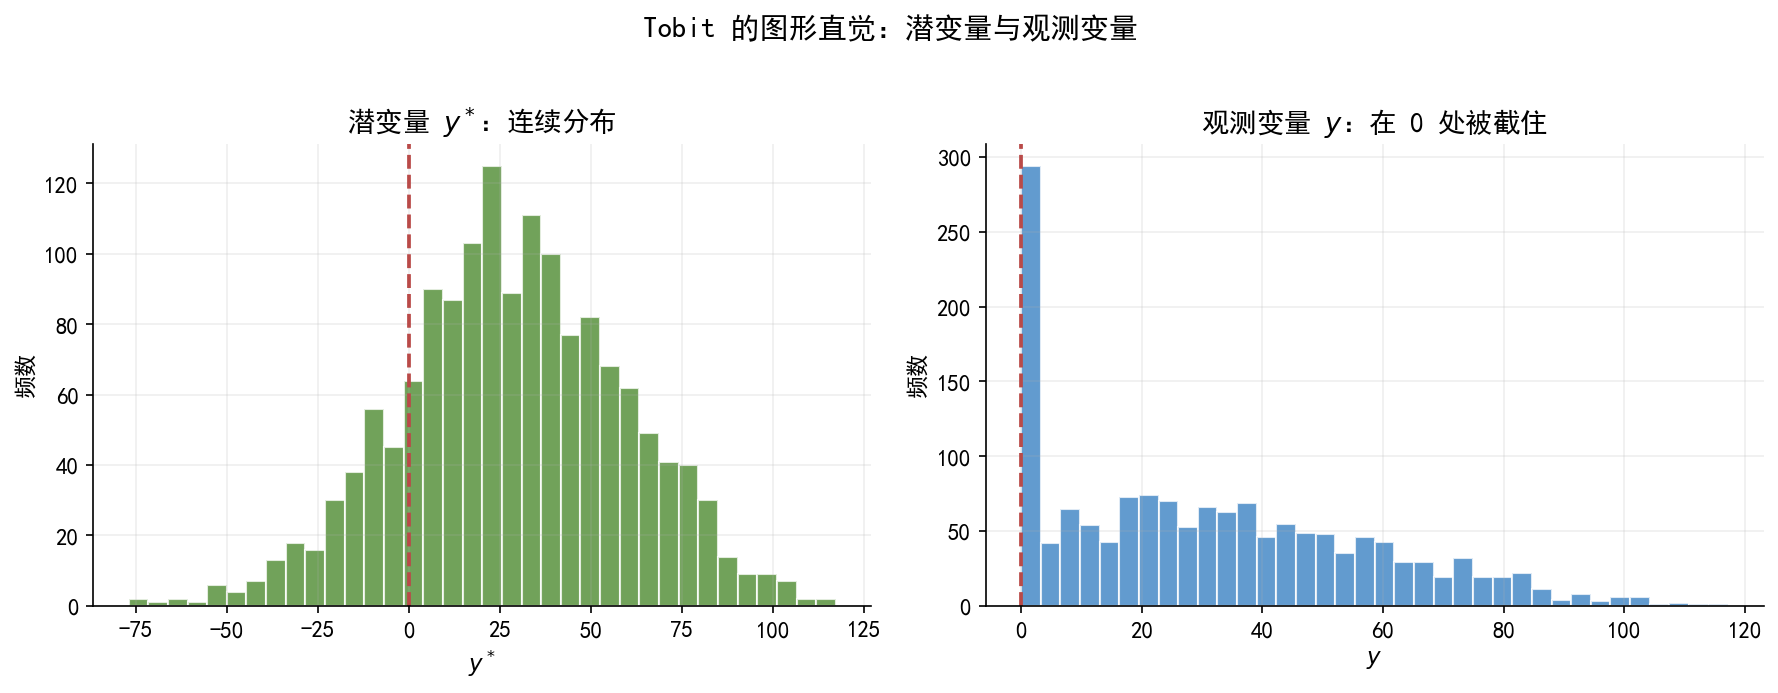

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(capex_df['capex_star'], bins=36, color=GREEN, alpha=0.80, edgecolor='white')
axes[0].axvline(0, color=RED, linestyle='--', linewidth=1.8)
axes[0].set_title('潜变量 $y^*$：连续分布')
axes[0].set_xlabel('$y^*$')
axes[0].set_ylabel('频数')

axes[1].hist(capex_df['capex'], bins=36, color=BLUE, alpha=0.80, edgecolor='white')
axes[1].axvline(0, color=RED, linestyle='--', linewidth=1.8)
axes[1].set_title('观测变量 $y$：在 0 处被截住')
axes[1].set_xlabel('$y$')
axes[1].set_ylabel('频数')

fig.suptitle('Tobit 的图形直觉：潜变量与观测变量', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'limit_dep_models_fig03_tobit_latent_observed.png')
plt.show()

## 5. fig04：Tobit 中一个解释变量的三重影响

Saved: .\figs\limit_dep_models_fig04_tobit_effects.png


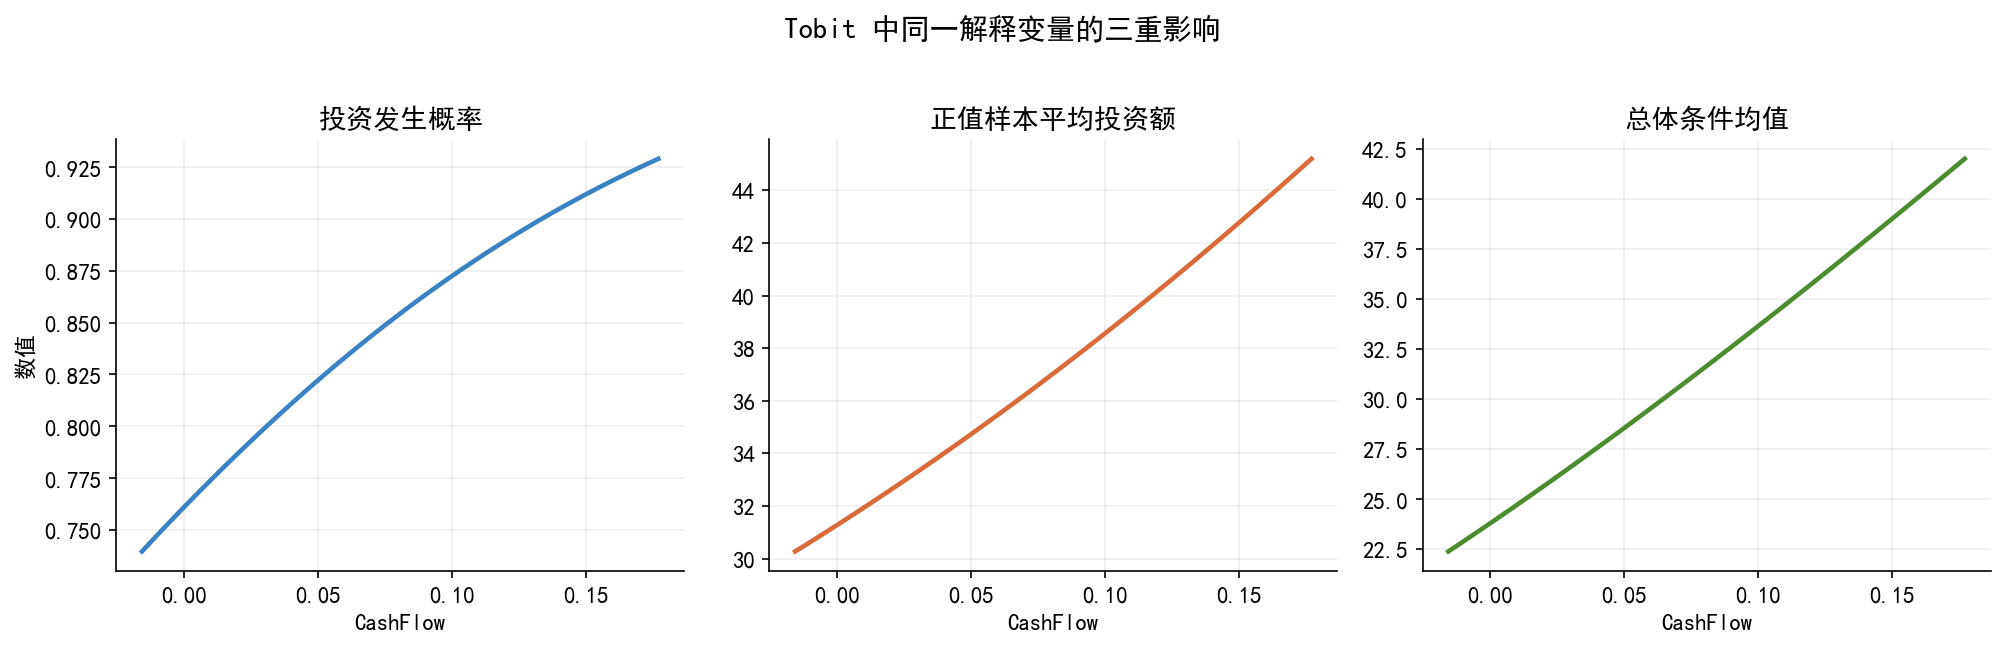

In [21]:
cash_grid = np.linspace(capex_df['cashflow'].quantile(0.05), capex_df['cashflow'].quantile(0.95), 80)
base_size = capex_df['size'].mean()
base_lev = capex_df['leverage'].mean()
base_growth = capex_df['growth'].mean()
sigma = 28
mu = 35 + 120 * cash_grid - 42 * base_lev + 18 * base_growth + 7 * (base_size - 8)
z = mu / sigma
prob_pos = norm.cdf(z)
cond_mean = mu + sigma * norm.pdf(z) / np.maximum(norm.cdf(z), 1e-8)
overall_mean = prob_pos * cond_mean

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
series = [
    (prob_pos, '投资发生概率', BLUE),
    (cond_mean, '正值样本平均投资额', ORANGE),
    (overall_mean, '总体条件均值', GREEN),
]
for ax, (yvals, title, color) in zip(axes, series):
    ax.plot(cash_grid, yvals, color=color, linewidth=2.2)
    ax.set_title(title)
    ax.set_xlabel('CashFlow')

axes[0].set_ylabel('数值')
fig.suptitle('Tobit 中同一解释变量的三重影响', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'limit_dep_models_fig04_tobit_effects.png')
plt.show()

## 6. fig05：Two-part 的两步决策流程

Saved: .\figs\limit_dep_models_fig05_twopart_flow.png


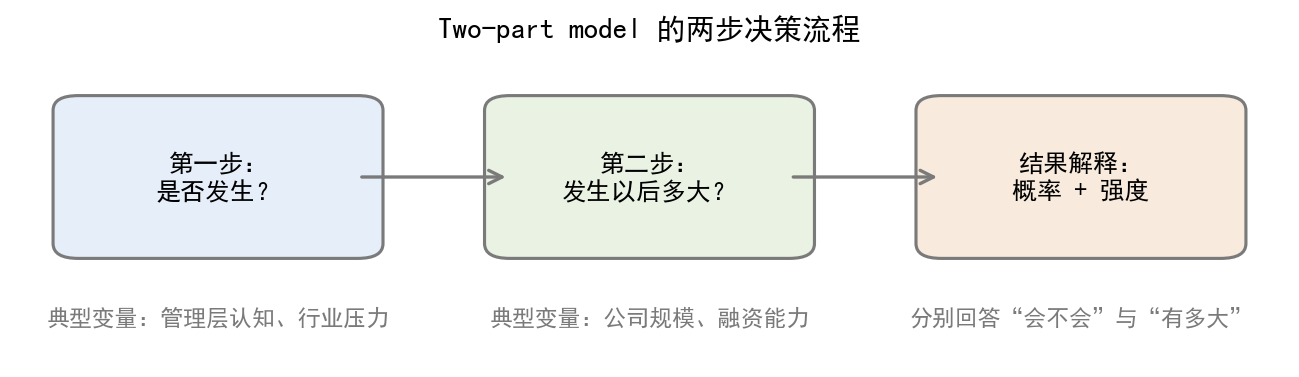

In [34]:
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.set_axis_off()

def flow_box(x, text, fc):
    patch = FancyBboxPatch((x, 0.40), 0.22, 0.18, boxstyle='round,pad=0.02',
                           linewidth=1.5, edgecolor=GRAY, facecolor=fc)
    ax.add_patch(patch)
    ax.text(x + 0.11, 0.49, text, ha='center', va='center', fontsize=12)

flow_box(0.05, '第一步：\n是否发生？', '#E6EEF9')
flow_box(0.39, '第二步：\n发生以后多大？', '#E9F2E3')
flow_box(0.73, '结果解释：\n概率 + 强度', '#F8EBDD')
ax.add_patch(FancyArrowPatch((0.27, 0.49), (0.39, 0.49), arrowstyle='->', mutation_scale=16, linewidth=1.6, color=GRAY))
ax.add_patch(FancyArrowPatch((0.61, 0.49), (0.73, 0.49), arrowstyle='->', mutation_scale=16, linewidth=1.6, color=GRAY))
ax.text(0.16, 0.29, '典型变量：管理层认知、行业压力', ha='center', fontsize=11, color=GRAY)
ax.text(0.50, 0.29, '典型变量：公司规模、融资能力', ha='center', fontsize=11, color=GRAY)
ax.text(0.84, 0.29, '分别回答“会不会”与“有多大”', ha='center', fontsize=11, color=GRAY)
ax.set_xlim(0, 1)
ax.set_ylim(0.24, 0.66)
ax.set_title('Two-part model 的两步决策流程', fontsize=14, pad=6)
fig.subplots_adjust(left=0.03, right=0.97, top=0.82, bottom=0.08)
save_fig(fig, 'limit_dep_models_fig05_twopart_flow.png')
plt.show()

## 7. fig06：Hurdle 的“两道门”

Saved: .\figs\limit_dep_models_fig06_hurdle_gates.png


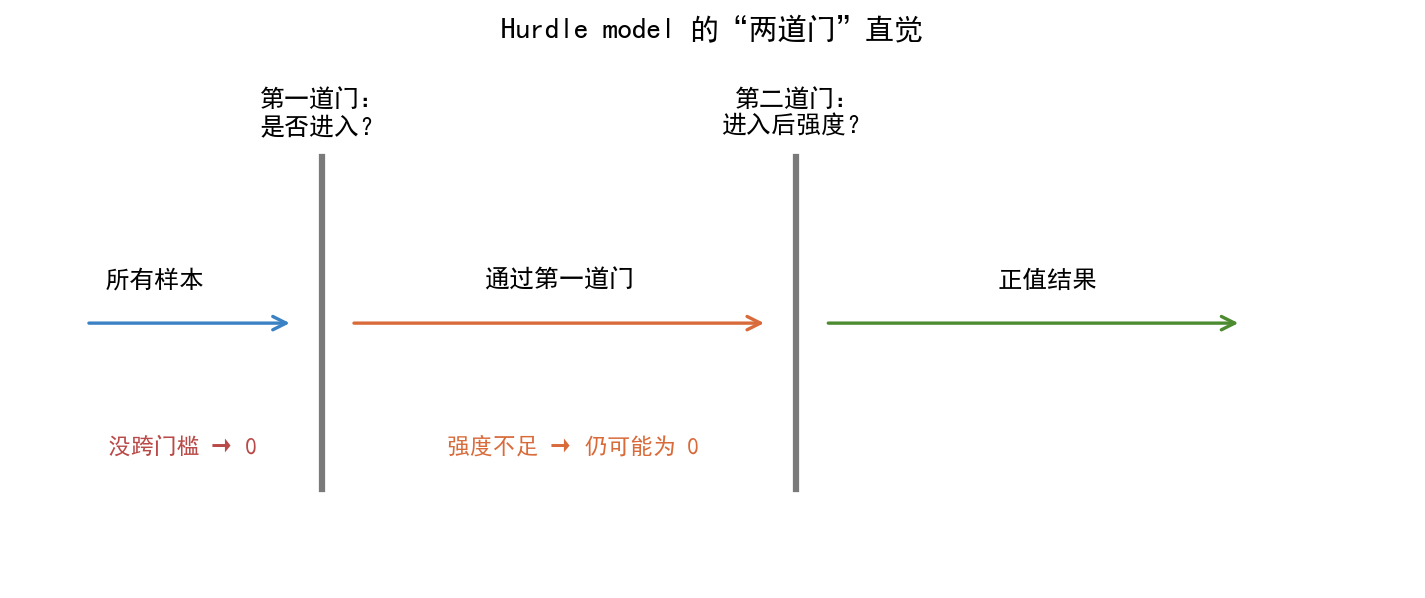

In [29]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.set_axis_off()

for x, label in [(0.22, '第一道门：\n是否进入？'), (0.56, '第二道门：\n进入后强度？')]:
    ax.plot([x, x], [0.18, 0.82], color=GRAY, linewidth=3)
    ax.text(x, 0.86, label, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.add_patch(FancyArrowPatch((0.05, 0.50), (0.20, 0.50), arrowstyle='->', mutation_scale=16, linewidth=1.6, color=BLUE))
ax.add_patch(FancyArrowPatch((0.24, 0.50), (0.54, 0.50), arrowstyle='->', mutation_scale=16, linewidth=1.6, color=ORANGE))
ax.add_patch(FancyArrowPatch((0.58, 0.50), (0.88, 0.50), arrowstyle='->', mutation_scale=16, linewidth=1.6, color=GREEN))
ax.text(0.10, 0.57, '所有样本', ha='center', fontsize=12)
ax.text(0.39, 0.57, '通过第一道门', ha='center', fontsize=12)
ax.text(0.74, 0.57, '正值结果', ha='center', fontsize=12)
ax.text(0.12, 0.25, '没跨门槛 → 0', ha='center', fontsize=11, color=RED)
ax.text(0.40, 0.25, '强度不足 → 仍可能为 0', ha='center', fontsize=11, color=ORANGE)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Hurdle model 的“两道门”直觉', fontsize=14, pad=12)
save_fig(fig, 'limit_dep_models_fig06_hurdle_gates.png')
plt.show()

## 8. fig07：Heckman 的样本选择机制

Saved: .\figs\limit_dep_models_fig07_heckman_selection.png


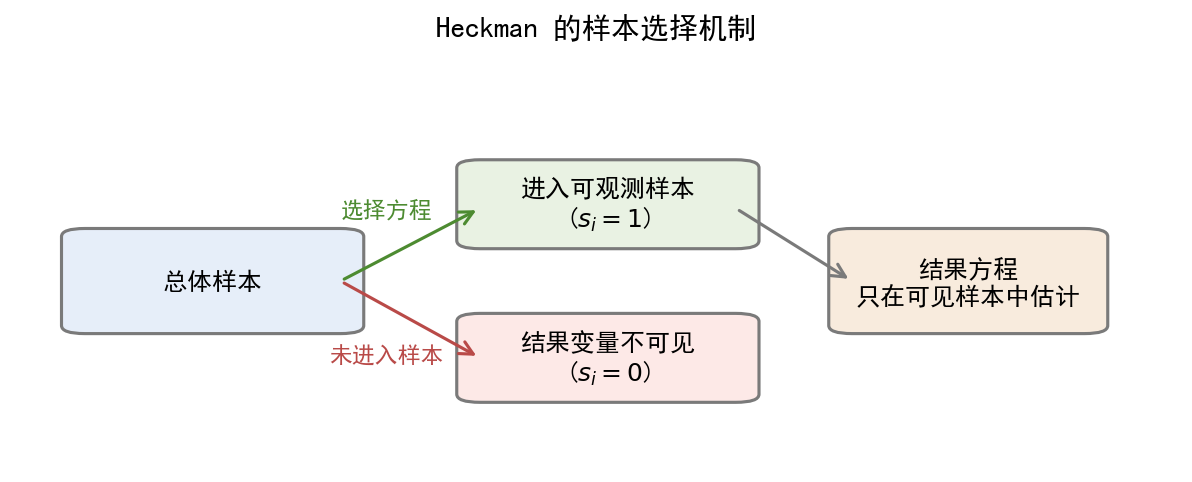

In [41]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_axis_off()

def add_box(x, y, w, h, text, fc):
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02',
                           linewidth=1.5, edgecolor=GRAY, facecolor=fc)
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=12)

add_box(0.06, 0.35, 0.22, 0.22, '总体样本', '#E6EEF9')
add_box(0.40, 0.56, 0.22, 0.18, '进入可观测样本\n($s_i=1$)', '#E9F2E3')
add_box(0.40, 0.18, 0.22, 0.18, '结果变量不可见\n($s_i=0$)', '#FDE9E7')
add_box(0.72, 0.35, 0.20, 0.22, '结果方程\n只在可见样本中估计', '#F8EBDD')
ax.add_patch(FancyArrowPatch((0.28, 0.46), (0.40, 0.64), arrowstyle='->', mutation_scale=16, linewidth=1.5, color=GREEN))
ax.add_patch(FancyArrowPatch((0.28, 0.46), (0.40, 0.27), arrowstyle='->', mutation_scale=16, linewidth=1.5, color=RED))
ax.add_patch(FancyArrowPatch((0.62, 0.64), (0.72, 0.46), arrowstyle='->', mutation_scale=16, linewidth=1.5, color=GRAY))
ax.text(0.28, 0.62, '选择方程', color=GREEN, fontsize=11, fontweight='bold')
ax.text(0.27, 0.26, '未进入样本', color=RED, fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Heckman 的样本选择机制', fontsize=14, pad=12)
save_fig(fig, 'limit_dep_models_fig07_heckman_selection.png')
plt.show()

## 9. fig08：Treatment effect 的处理组自选择

Saved: .\figs\limit_dep_models_fig08_treatment_selection.png


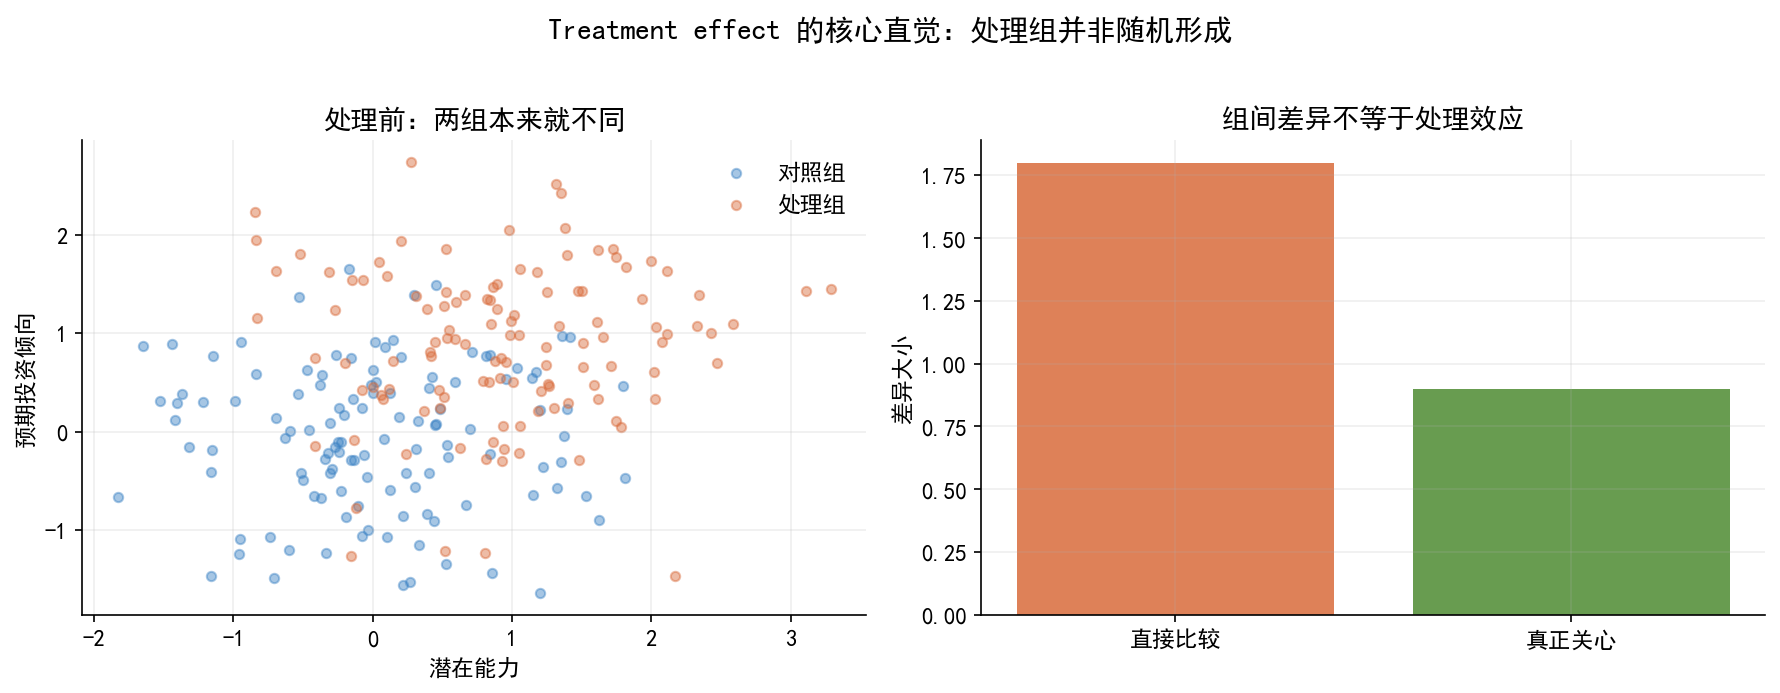

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

np.random.seed(7)
x0 = np.random.normal(0.0, 0.8, 120)
y0 = np.random.normal(0.0, 0.8, 120)
x1 = np.random.normal(1.0, 0.8, 120)
y1 = np.random.normal(1.0, 0.8, 120)

axes[0].scatter(x0, y0, s=20, alpha=0.45, color=BLUE, label='对照组')
axes[0].scatter(x1, y1, s=20, alpha=0.45, color=ORANGE, label='处理组')
axes[0].set_title('处理前：两组本来就不同')
axes[0].set_xlabel('潜在能力')
axes[0].set_ylabel('预期投资倾向')
axes[0].legend(frameon=False)

axes[1].bar(['直接比较', '真正关心'], [1.8, 0.9], color=[ORANGE, GREEN], alpha=0.85)
axes[1].set_title('组间差异不等于处理效应')
axes[1].set_ylabel('差异大小')

fig.suptitle('Treatment effect 的核心直觉：处理组并非随机形成', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'limit_dep_models_fig08_treatment_selection.png')
plt.show()

## 10. fig09：流量型结果变量的典型分布

Saved: .\figs\limit_dep_models_fig09_flow_distribution.png


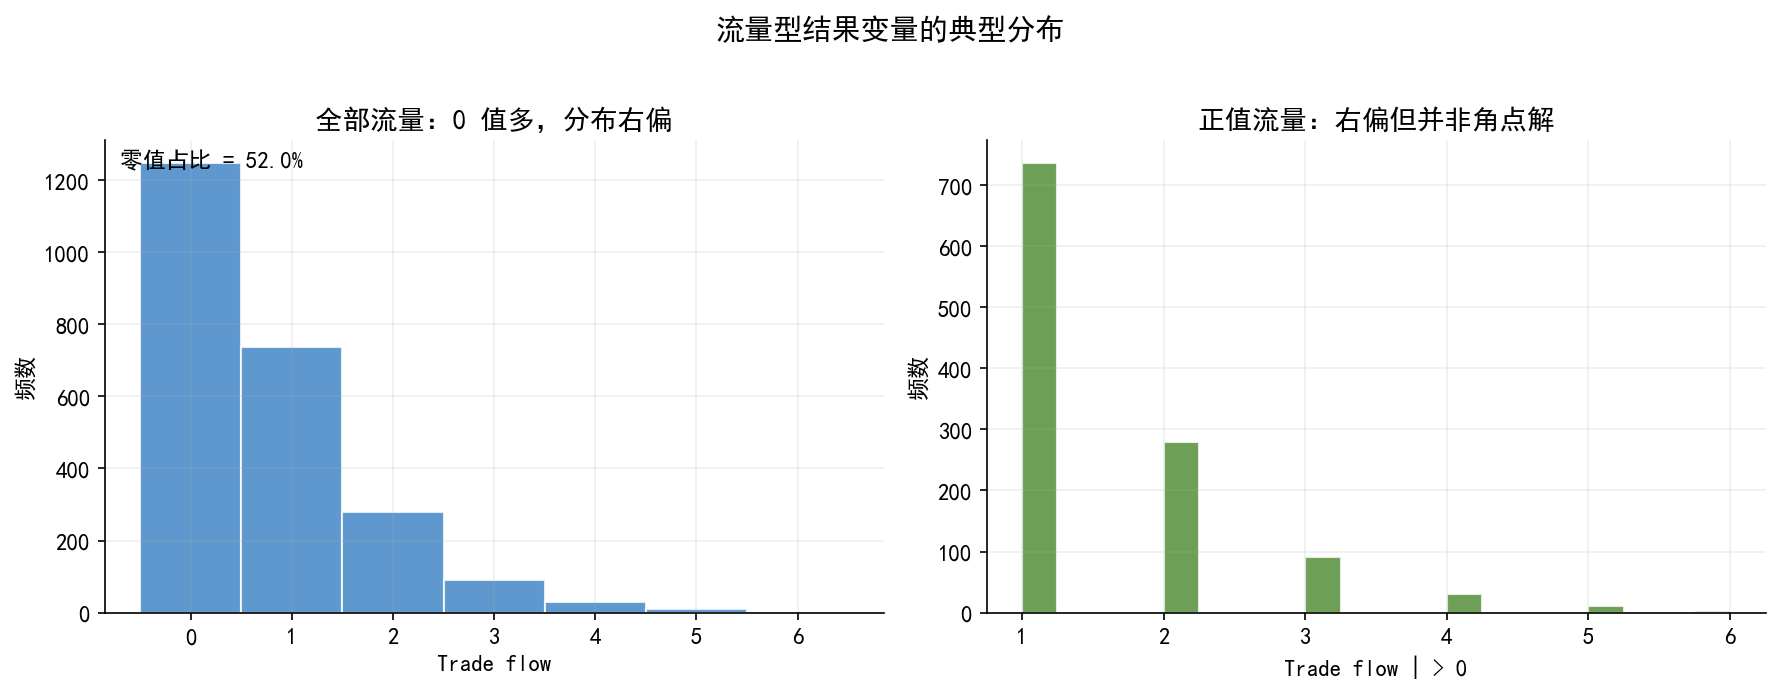

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(flow_df['trade_flow'], bins=np.arange(flow_df['trade_flow'].max() + 2) - 0.5,
             color=BLUE, alpha=0.82, edgecolor='white')
axes[0].set_title('全部流量：0 值多，分布右偏')
axes[0].set_xlabel('Trade flow')
axes[0].set_ylabel('频数')
panel_title(axes[0], f"零值占比 = {(flow_df['trade_flow'] == 0).mean():.1%}")

positive_flow = flow_df.loc[flow_df['trade_flow'] > 0, 'trade_flow']
axes[1].hist(positive_flow, bins=20, color=GREEN, alpha=0.82, edgecolor='white')
axes[1].set_title('正值流量：右偏但并非角点解')
axes[1].set_xlabel('Trade flow | > 0')
axes[1].set_ylabel('频数')

fig.suptitle('流量型结果变量的典型分布', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'limit_dep_models_fig09_flow_distribution.png')
plt.show()

## 11. fig10：对数 OLS 与 PPMLHDFE 的直观对比

Saved: .\figs\limit_dep_models_fig10_ppml_vs_logols.png


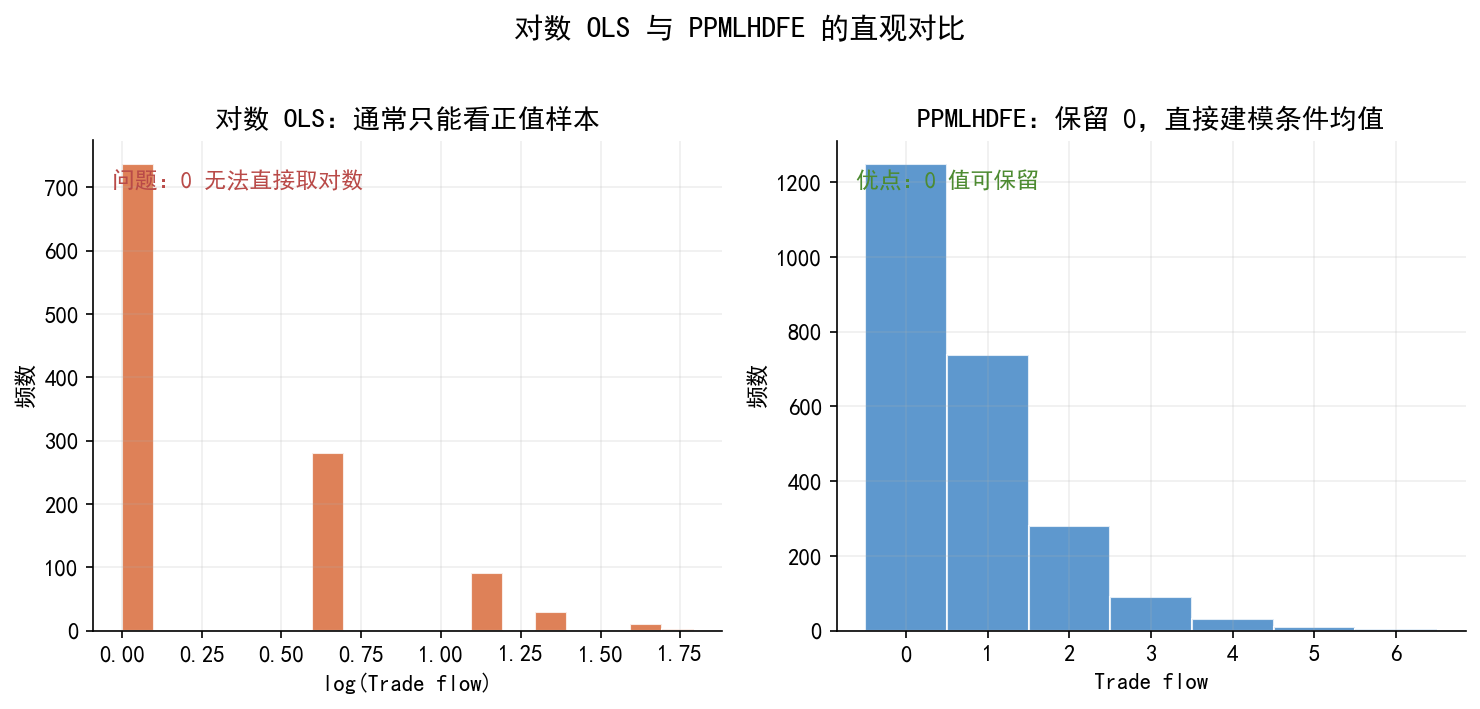

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))

axes[0].hist(np.log(positive_flow), bins=18, color=ORANGE, alpha=0.85, edgecolor='white')
axes[0].set_title('对数 OLS：通常只能看正值样本')
axes[0].set_xlabel('log(Trade flow)')
axes[0].set_ylabel('频数')
axes[0].text(0.03, 0.94, '问题：0 无法直接取对数', transform=axes[0].transAxes, ha='left', va='top', fontsize=11, color=RED)

axes[1].hist(flow_df['trade_flow'], bins=np.arange(flow_df['trade_flow'].max() + 2) - 0.5,
             color=BLUE, alpha=0.82, edgecolor='white')
axes[1].set_title('PPMLHDFE：保留 0，直接建模条件均值')
axes[1].set_xlabel('Trade flow')
axes[1].set_ylabel('频数')
axes[1].text(0.03, 0.94, '优点：0 值可保留', transform=axes[1].transAxes, ha='left', va='top', fontsize=11, color=GREEN)

fig.suptitle('对数 OLS 与 PPMLHDFE 的直观对比', fontsize=14, y=1.02)
fig.tight_layout()
save_fig(fig, 'limit_dep_models_fig10_ppml_vs_logols.png')
plt.show()